In [17]:
%load_ext autoreload
%autoreload 2
%load_ext rpy2.ipython

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [18]:
import ibis
import pandas as pd

import src
from src.load import DataLoader

ibis.options.interactive = True
r_colormap_channel = src.r_colormap_name
r_colormap_party = src.r_colormap_party
r_out = str(src.OUT)
pd.options.display.float_format = "{:.1f}".format

In [19]:
%%R -i r_colormap_channel -i r_colormap_party -i r_out

suppressMessages(library(tidyverse))
library(ggplot2)
library(ggeffects)
library(here)
library(ggpubr)

options(scipen = 999)

cmap <- setNames(r_colormap_channel$color, r_colormap_channel$channel)
pmap <- setNames(r_colormap_party$color, r_colormap_party$party)

# Load Data

In [20]:
dl = DataLoader()

videos = dl.channels().join(dl.videos(filtered=True), "channel_id").to_pandas()

sentences = dl.sentences(filtered=True).join(dl.popbert(filtered=False), "sentence_id").to_pandas()

sents = sentences.groupby("video_id", observed=True).agg(
    n_sents=("video_id", "size"),
    n_elite=("elite", "sum"),
    n_pplcentr=("pplcentr", "sum"),
    avg_elite=("elite", "mean"),
    avg_pplcentr=("pplcentr", "mean"),
)

# Dataset Summary Table

In [21]:
channel_overview = (
    videos.loc[videos.video_was_live == False]
    .merge(sents, on="video_id", how="left")
    .groupby("channel", observed=True)
    .agg(
        chFollowers=("channel_follower_count", "first"),
        chName=("channel_uploader_id", "first"),
        nShortVids=("video_is_short", lambda x: (x == 1).sum()),
        nLongVids=("video_is_short", lambda x: (x == 0).sum()),
        nVids=("video_was_live", lambda x: (x == 0).sum()),
        nLikesNA=("video_likes", lambda x: x.isna().sum()),
        meanViews=("video_views", "mean"),
        medianViews=("video_views", "median"),
        meanLikes=("video_likes", "mean"),
        medianLikes=("video_likes", "median"),
        meanVidLen=("video_duration", "mean"),
        nSentences=("n_sents", "sum"),
        first_video=("video_datetime_upload", "min"),
        latest_video=("video_datetime_upload", "max"),
    )
)

In [22]:
inlines = src.OUT / "manuscript/inlines"
inlines.mkdir(exist_ok=True)

In [23]:
# number of broken transcripts

broken_transcripts = dl.broken_transcripts(filtered=True).to_pandas()
n_broken = len(broken_transcripts)

n_broken = f"{n_broken:,.0f}"
p = inlines / "n_broken.txt"
p.unlink(missing_ok=True)
p.write_text(n_broken)
print(f"faulty transcripts: {n_broken}")

faulty transcripts: 142


In [24]:
# sum of durations

sum_of_seconds = videos.video_duration.sum()
hour_duration = f"{round(sum_of_seconds / 60 / 60, 1):,.1f}"
p = inlines / "sum_duration.txt"
p.unlink(missing_ok=True)
p.write_text(hour_duration)
print(f"Total sum of video durations: {hour_duration} hours")

Total sum of video durations: 2,339.7 hours


In [25]:
# number of videos

count_videos = len(videos)
count_videos = f"{count_videos:,.0f}"
p = inlines / "n_videos.txt"
p.unlink(missing_ok=True)
p.write_text(count_videos)
print(f"Total number of valid videos: {count_videos}")

Total number of valid videos: 19,347


In [26]:
# number of sentencs

count_sents = len(sentences)
count_sents = f"{count_sents:,.0f}"
p = inlines / "n_sents.txt"
p.unlink(missing_ok=True)
p.write_text(count_sents)
print(f"Total number of valid sentences: {count_sents}")

Total number of valid sentences: 1,282,738


In [27]:
summary_table = channel_overview.drop(["first_video", "latest_video"], axis=1)

summary_table

,chFollowers,chName,nShortVids,nLongVids,nVids,nLikesNA,meanViews,medianViews,meanLikes,medianLikes,meanVidLen,nSentences
channel,,,,,,,,,,,,
AfD BT,539000,@AfDFraktionimBundestag,665,5562,6227,0,54654.2,16714.0,4443.8,2062.0,411.4,378326
AfD DE,340000,@AfDTV,654,1245,1899,110,56958.2,20265.0,4493.6,2610.0,541.3,173464
CDU DE,30800,@cdutv,565,322,887,1,22000.5,1390.0,197.4,30.0,534.2,74430
CDU/CSU BT,8050,@cducsu,445,281,726,620,2031.7,252.5,137.2,25.5,604.8,60713
CSU BT,4930,@csuimbundestag9622,16,394,410,410,6202.0,320.5,NaN,NaN,349.0,20459
CSU DE,6890,@csumedia,115,69,184,4,25480.9,1000.5,47.1,25.5,410.9,13753
FDP BT,24500,@fdpbt,298,346,644,1,24525.5,1695.0,291.9,60.0,379.7,39222
FDP DE,29600,@FDP,433,325,758,757,24372.7,1243.5,104.0,104.0,527.3,57468
Greens BT,3000,@gruenebundestag,140,93,233,0,4642.5,1003.0,57.6,17.0,333.3,11572


In [28]:
path = src.OUT / "tables/videos_per_channel.csv"
path.unlink(missing_ok=True)
summary_table[
    [
        "nShortVids",
        "nLongVids",
        "nVids",
        "meanVidLen",
    ]
].to_csv(path)

In [29]:
path = src.OUT / "tables/channel_descriptives.csv"
path.unlink(missing_ok=True)
summary_table[
    [
        "chName",
        "chFollowers",
    ]
].to_csv(path)

In [ ]:
path = src.OUT / "tables/video_descriptives_per_channel.csv"
path.unlink(missing_ok=True)
summary_table[["meanViews", "medianViews", "meanLikes", "medianLikes", "nSentences"]].fillna(
    "NA",
).to_csv(path)

AttributeError: 'DataFrame' object has no attribute 'fill_na'

# View Count Violin Plot

In [31]:
df = videos.merge(sents, on="video_id")

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: Removed 2000 rows containing non-finite outside the scale range
(`stat_boxplot()`). 

R[write to console]: 2: Removed 2000 rows containing non-finite outside the scale range
(`stat_ydensity()`). 

R[write to console]: 3: Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes. 



In addition: Warning messages:
1: Removed 2000 rows containing non-finite outside the scale range
(`stat_boxplot()`). 
2: Removed 2000 rows containing non-finite outside the scale range
(`stat_ydensity()`). 
3: Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes. 


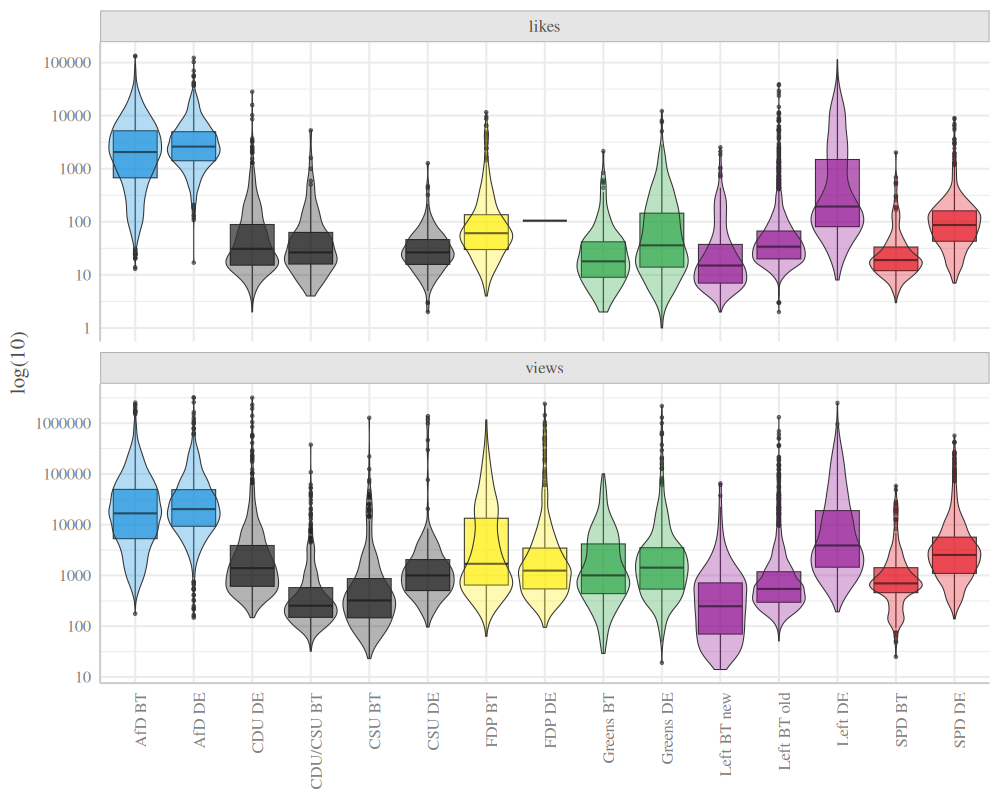

In [32]:
%%R -i df -w 1000 -h 800

df_plot <- df |>
   mutate(
      likes = video_likes + 1,
      views = video_views + 1,
) |>
pivot_longer(
   c(likes, views),
   names_to = "var",
   values_to = "val"
)

plot <- ggplot(df_plot, aes(x=channel, y=val, fill=channel)) +
   geom_boxplot(alpha=0.6) +
   geom_violin(alpha=0.3, trim=T, scale="width") +
   scale_y_continuous(trans="log10", breaks=scales::breaks_log(n=8)) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 21
   ) +
   theme(
      axis.text.x=element_text(angle=90, hjust=1),
      axis.ticks.x=element_blank(),
      axis.title.x=element_blank(),
      legend.position = "none"
   ) +
   facet_wrap(~var, ncol=1, scales="free_y") +
   ylab("log(10)")

plot

p <- here(r_out, "/figures/view_count.svg")
if (file.exists(p)) file.remove(p)
ggsave(p, width=12.4, height=12.4)
plot

# Populism Amount Plot

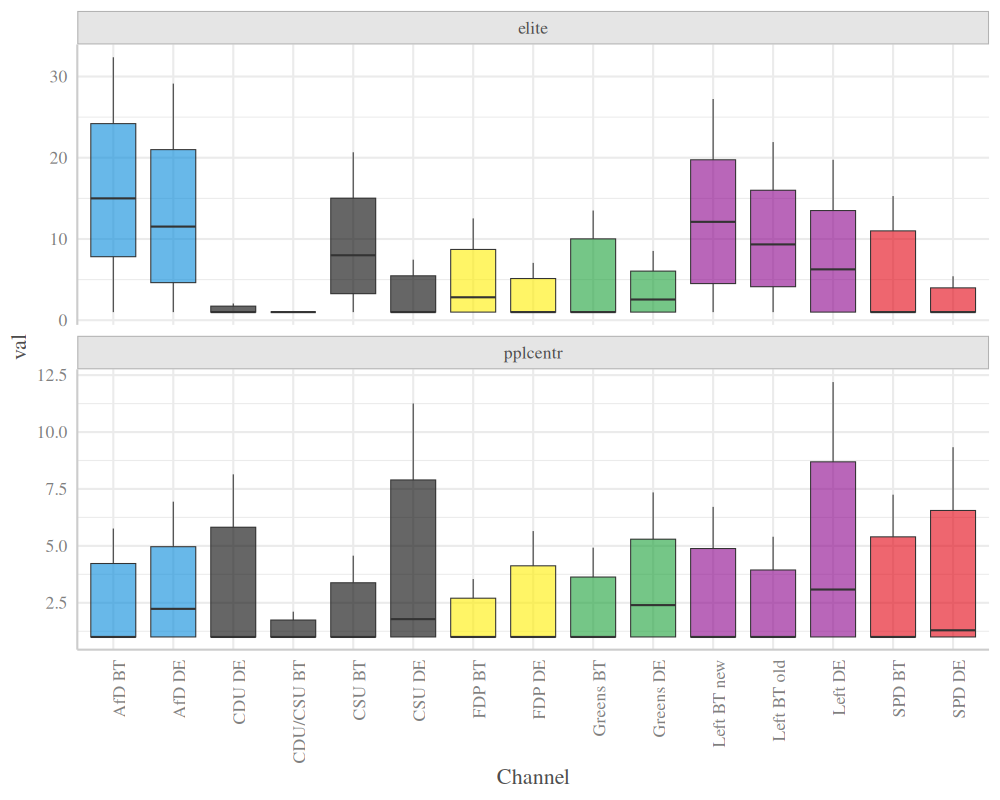

In [33]:
%%R -i df -w 1000 -h 800

df_plot <- df |>
   mutate(
      elite = (n_elite / n_sents * 100) + 1,
      pplcentr = (n_pplcentr / n_sents * 100) + 1,
) |>
pivot_longer(
   c(elite, pplcentr),
   names_to = "var",
   values_to = "val"
)


plot <- ggplot(df_plot, aes(x=channel, y=val, fill=channel)) +
   geom_boxplot(alpha=0.6, outliers=F, coef=0.5) +
   scale_color_manual(values=cmap, aesthetics=c("color", "fill")) +
   theme_ggeffects(
      base_family = "serif",
      base_size = 22
   ) +
   theme(
      axis.text.x=element_text(angle=90, hjust=1),
      legend.position = "none"
   ) +
   xlab("Channel") +
   facet_wrap(~var, ncol=1, scales="free_y")

plot

p <- here(r_out, "/figures/populism_per_party.svg")
if (file.exists(p)) file.remove(p)
ggsave(p, width=12.4, height=12.4)
plot